🚀 #**Procesamiento y Limpieza de Datos con Python: Kiva Crowdfunding**

*Autoras:* Ana Paula Montiel & Yasira Blanco

-----------------------------------------------------------------

**📝 Descripción del proyecto**

*Este proyecto aplica las mejores prácticas de limpieza y preparación de datos utilizando Python. El objetivo es transformar los datos brutos del dataset "Data Science for Good: Kiva Crowdfunding" en un conjunto de datos estructurado y consistente, listo para análisis avanzado o modelado predictivo.*

El flujo de trabajo se divide en:

* Importación y exploración inicial.

* Diagnóstico técnico y visual (Snapshot Inicial).

* Transformaciones y limpieza paso a paso.

* Validación post-limpieza y comparación (Snapshot Final).

-----------------------------------------------------------------
**🎯 Objetivos concretos**
Corregir tipos de datos, formatos de fecha y valores inconsistentes.

Gestionar duplicados y valores faltantes de forma documentada.

Garantizar la reproducibilidad del proceso mediante funciones automatizadas.

Exportar un artefacto final optimizado (CSV/Parquet).

-----------------------------------------------------------------

**🧰 Tecnologías y Librerías**
Entorno: Google Colab / Jupyter Notebook

Librerías: pandas, numpy, missingno, matplotlib

Dataset: Kiva Crowdfunding (Kaggle)

### 📋 Descripción
proyecto del Bootcamp de analisis de datos sobre el dataset kiva_loans

### 🛠️ Configuración Inicial
> **Nota sobre los datos:** Por razones de tamaño, el dataset original (`kiva_loans.csv`) no se encuentra en el repositorio de GitHub.



In [1]:
#importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from google.colab import data_table
from IPython.display import display

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")

Librerías listas para la limpieza.


In [2]:
df = pd.read_csv('kiva_loans.csv')

Mostramos la tabla para un primer vistazo de los datos.

In [3]:
#llamada al dataframe
df.head(10)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16,NaN,female,monthly,2014-01-01
5,1080148,250.0,250.0,Services,Services,purchase leather for my business using ksh 20000.,KE,Kenya,NaN,KES,NaN,2014-01-01 10:06:19+00:00,2014-01-30 01:42:48+00:00,2014-01-29 14:14:57+00:00,4.0,6,NaN,female,irregular,2014-01-01
6,653067,200.0,200.0,Dairy,Agriculture,To purchase a dairy cow and start a milk produ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:51:02+00:00,2013-12-16 08:00:00+00:00,2014-01-01 17:18:09+00:00,43.0,8,"user_favorite, user_favorite",female,bullet,2014-01-01
7,653078,400.0,400.0,Beauty Salon,Services,to buy more hair and skin care products.,PK,Pakistan,Ellahabad,PKR,245.0,2014-01-01 11:46:01+00:00,2013-12-20 08:00:00+00:00,2014-01-10 18:18:44+00:00,14.0,8,"#Elderly, #Woman Owned Biz",female,monthly,2014-01-01
8,653082,475.0,475.0,Manufacturing,Manufacturing,"to purchase leather, plastic soles and heels i...",PK,Pakistan,Lahore,PKR,245.0,2014-01-01 11:49:43+00:00,2013-12-20 08:00:00+00:00,2014-01-01 18:47:21+00:00,14.0,19,user_favorite,female,monthly,2014-01-01
9,653048,625.0,625.0,Food Production/Sales,Food,"to buy a stall, gram flour, ketchup, and coal ...",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 05:41:03+00:00,2013-12-17 08:00:00+00:00,2014-01-03 15:45:04+00:00,11.0,24,NaN,female,irregular,2014-01-01


Radiografía de los datos (SNAPSHOT INICIAL) recuento y otros; filas, columnas, celdas totales, nulos, ...

In [4]:
#FUNCIÓN 1: El análisis técnico
def radiografia_tecnica(df):
    print("=" * 60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("=" * 60)

    #Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Añadir valores de ejemplo (primer valor no nulo)
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    # Aplicar formato para que la tabla sea legible
    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show() # Para asegurar que el gráfico se imprima aquí
    #check rápido
    print(" ")
    print("------------------------------------------------------------------")
    if 'loan_amount' in df.columns:
      print(f"¿Hay montos negativos o cero?: { (df['loan_amount'] <= 0).any() }")
    else:
      print("⚠️ La columna 'loan_amount' no se encontró para el check de coherencia.")
    print("------------------------------------------------------------------")
#FUNCIÓN 2: El plan de acción (Resumen)
def plan_accion_datos(df):
    print("\n" + "=" * 60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("=" * 60)

    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    if 'loan_amount' in df.columns:
        anomalos = (df['loan_amount'] <= 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Corregir {anomalos} préstamos con monto <= 0.")
#Sugerencia de fechas automática
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    if cols_fecha:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_fecha}")

    print("-" * 60)
    print("  TIP: Una vez corregidos estos puntos, vuelve a ejecutar esta celda.")
    print("="*60)
#FUNCIÓN 3: Comparativo Snapshot
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    metrics = {
        'Métrica': [
            'Filas Totales',
            'Columnas',
            'Celdas con Nulos',
            '% Global de Nulos',
            'Filas Duplicadas',
            'Memoria (MB)'
        ],
        'Snapshot Inicial': [
            f"{len(df_inicial):,}",
            df_inicial.shape[1],
            f"{df_inicial.isnull().sum().sum():,}",
            f"{(df_inicial.isnull().sum().sum() / df_inicial.size) * 100:.2f}%",
            df_inicial.duplicated().sum(),
            f"{df_inicial.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ],
        'Snapshot Final': [
            f"{len(df_final):,}",
            df_final.shape[1],
            f"{df_final.isnull().sum().sum():,}",
            f"{(df_final.isnull().sum().sum() / df_final.size) * 100:.2f}%",
            df_final.duplicated().sum(),
            f"{df_final.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]
    }

    comparativa_df = pd.DataFrame(metrics)

    # Aplicamos un estilo para resaltar las diferencias
    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    # Cálculo de filas eliminadas
    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

Llamada a la función radiografía para mostrar datos

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 671,205
  • Columnas: 20
  • Celdas totales: 13,424,100
  • Datos faltantes: 300,911 (2.24%)
  • Filas duplicadas: 0
  • Uso de memoria: 621.15 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
id,int64,671205,0,0.00%,671205,100.00%,653051
funded_amount,float64,671205,0,0.00%,610,0.09%,300.000000
loan_amount,float64,671205,0,0.00%,479,0.07%,300.000000
activity,object,671205,0,0.00%,163,0.02%,Fruits & Vegetables
sector,object,671205,0,0.00%,15,0.00%,Food
use,object,666973,4232,0.63%,424912,63.31%,"To buy seasonal, fresh fruits to sell."
country_code,object,671197,8,0.00%,86,0.01%,PK
country,object,671205,0,0.00%,87,0.01%,Pakistan
region,object,614405,56800,8.46%,12695,1.89%,Lahore
currency,object,671205,0,0.00%,67,0.01%,PKR


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
id,671205.0,993248.593734,196611.275423,653047.0,823072.0,992780.0,1163653.0,1340339.0
funded_amount,671205.0,785.995061,1130.398941,0.0,250.0,450.0,900.0,100000.0
loan_amount,671205.0,842.397107,1198.660073,25.0,275.0,500.0,1000.0,100000.0
partner_id,657698.0,178.199616,94.247581,9.0,126.0,145.0,204.0,536.0
term_in_months,671205.0,13.739022,8.598919,1.0,8.0,13.0,14.0,158.0
lender_count,671205.0,20.590922,28.459551,0.0,7.0,13.0,24.0,2986.0


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


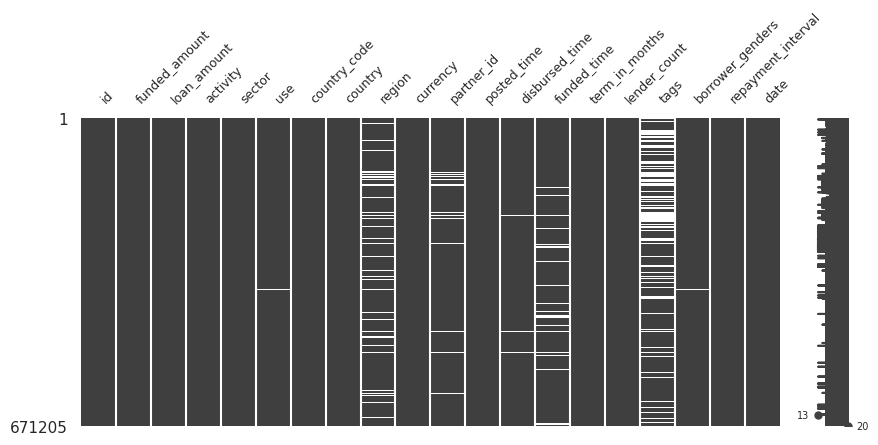

 
------------------------------------------------------------------
¿Hay montos negativos o cero?: False
------------------------------------------------------------------


In [5]:
df = pd.read_csv('kiva_loans.csv')
df_original = df.copy() # <--- GUARDAMOS LA "FOTO" INICIAL
radiografia_tecnica(df)

Llamada a la función plan de acción para mostrar resumen

In [6]:
plan_accion_datos(df)


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] FORMATO: Convertir a datetime: ['posted_time', 'disbursed_time', 'funded_time', 'date']
------------------------------------------------------------
  TIP: Una vez corregidos estos puntos, vuelve a ejecutar esta celda.


# **INICIAMOS LIMPIEZA**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-nul

In [8]:
# Eliminamos la columna 'tags'
df = df.drop(columns=['tags'], errors='ignore')
# convertimos las columnas de fecha a datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['posted_time'] = pd.to_datetime(df['posted_time'], errors='coerce')
df['disbursed_time'] = pd.to_datetime(df['disbursed_time'], errors='coerce')
df['funded_time'] = pd.to_datetime(df['funded_time'], errors='coerce')
# verificamos de nuevo la informacion para ver si se han modificado correctamente
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  671205 non-null  int64              
 1   funded_amount       671205 non-null  float64            
 2   loan_amount         671205 non-null  float64            
 3   activity            671205 non-null  object             
 4   sector              671205 non-null  object             
 5   use                 666973 non-null  object             
 6   country_code        671197 non-null  object             
 7   country             671205 non-null  object             
 8   region              614405 non-null  object             
 9   currency            671205 non-null  object             
 10  partner_id          657698 non-null  float64            
 11  posted_time         671205 non-null  datetime64[ns, UTC]
 12  disbursed_time  

In [9]:
# contar filas que puedan ser exactamente iguales en todas las columnas
total_duplicados = df.duplicated().sum()
print(f"se han encontrado {total_duplicados} filas duplicadas exactas.")
#contamos valores nulos por columna
nulos_por_columna = df.isnull().sum()
#mostramos columnas que tienen al menos un nulo
print("columnas con valores faltantes:")
print(nulos_por_columna[nulos_por_columna > 0])

se han encontrado 0 filas duplicadas exactas.
columnas con valores faltantes:
use                  4232
country_code            8
region              56800
partner_id          13507
disbursed_time       2396
funded_time         48331
borrower_genders     4221
dtype: int64


In [10]:
# Convertimos celdas que solo tienen espacios o están vacías en NaN (nulos reales)
df = df.replace(r'^\s*$', np.nan, regex=True)

# Ahora volvemos a contar nulos reales
print("Nulos reales detectados tras la limpieza de espacios:")
print(df.isnull().sum().sum())

# Borramos las filas que tengan nulos en columnas IMPORTANTES
# borramos filas donde falte el 'partner_id' o 'disbursed_time'
df.dropna(subset=['partner_id', 'disbursed_time'], inplace=True)

print(f"\n--- RESULTADO FINAL ---")
print(f"Número de filas actual: {df.shape[0]}")

Nulos reales detectados tras la limpieza de espacios:
129496

--- RESULTADO FINAL ---
Número de filas actual: 657698


In [11]:
# comprobamos si siguen habiendo nulos
print(df[['partner_id', 'disbursed_time']].isnull().sum())

partner_id        0
disbursed_time    0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657698 entries, 0 to 671204
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  657698 non-null  int64              
 1   funded_amount       657698 non-null  float64            
 2   loan_amount         657698 non-null  float64            
 3   activity            657698 non-null  object             
 4   sector              657698 non-null  object             
 5   use                 653889 non-null  object             
 6   country_code        657690 non-null  object             
 7   country             657698 non-null  object             
 8   region              614405 non-null  object             
 9   currency            657698 non-null  object             
 10  partner_id          657698 non-null  float64            
 11  posted_time         657698 non-null  datetime64[ns, UTC]
 12  disbursed_time      6

In [13]:
df['region'] = df['region'].fillna('No especificada')
df['use'] = df['use'].fillna('Sin información de uso')
df['country_code'] = df['country_code'].fillna('NULL')
df['borrower_genders'] = df['borrower_genders'].fillna('No especificado')
print("✅ Tratamiento de valores faltantes finalizado.")
print(df.isnull().sum())

✅ Tratamiento de valores faltantes finalizado.
id                        0
funded_amount             0
loan_amount               0
activity                  0
sector                    0
use                       0
country_code              0
country                   0
region                    0
currency                  0
partner_id                0
posted_time               0
disbursed_time            0
funded_time           46176
term_in_months            0
lender_count              0
borrower_genders          0
repayment_interval        0
date                      0
dtype: int64


CRITERIO: Aplicamos filtrado selectivo. La fila de tags ha sido eliminada por tener un exceso de errores y informacion irrelevante ahora mismo. A continuacion solo eliminamos filas con nulos en partner_id y disbursed_time porque consideramos que son variables importantes para el analisis, pero conservamos nulos por ejemplo en funded_time ya que son prestamos que no han alcandado la financiacion y son datos utiles. En region, use y borrower_genders sustituimos los nulos por etiquetas no especificadas para no dejar huecos


In [14]:
#Comenzamos a normalizar, a continuacion eliminamos espacios y mayusculas

columnas_a_normalizar = [
    'activity', 'sector', 'use', 'country_code',
    'country', 'region', 'currency', 'borrower_genders', 'repayment_interval'
]
for col in columnas_a_normalizar:
  df[col] = df[col].str.strip().str.lower()
print(" Todas las columnas de texto han sido normalizadas.")

 Todas las columnas de texto han sido normalizadas.


In [15]:
# Resumen estadístico de las columnas de dinero
print("📊 Resumen de montos:")
resumen = df[['funded_amount', 'loan_amount']].describe()
display(resumen)

📊 Resumen de montos:


,funded_amount,loan_amount
count,657698.000000,657698.000000
mean,770.778001,816.263163
std,1066.365512,1110.912347
min,0.000000,25.000000
25%,250.000000,275.000000
50%,450.000000,500.000000
75%,900.000000,975.000000
max,100000.000000,100000.000000


In [16]:
#Una vez normalizamos, volvermos a pasar drop.duplicate por si ahora sí hubiera algún duplicado
duplicados_totales = df.duplicated().sum()
print(f"Filas totalmente duplicadas: {duplicados_totales}")
# 2. Verificar si hay IDs de préstamo repetidos (aunque el resto de la fila varíe)
duplicados_id = df.duplicated(subset='id').sum()
print(f"IDs de préstamo duplicados: {duplicados_id}")

Filas totalmente duplicadas: 0
IDs de préstamo duplicados: 0


In [17]:
# Verificamos el nuevo tamaño del dataset
print(f"Nuevo tamaño del dataset: {df.shape}")

Nuevo tamaño del dataset: (657698, 19)


# **MOSTRAR GRÁFICOS**

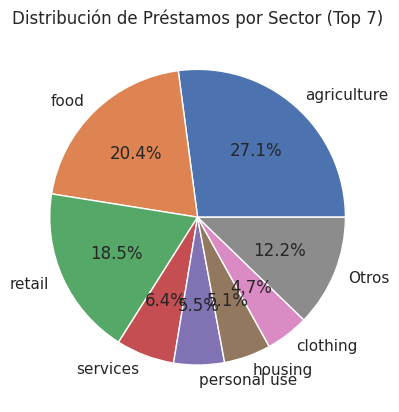

In [18]:
# A continuacion mostraremos un grafico por sectores, hacemos un top 7 para poder simplificar mucho mas la vista
# Contamos cuántos préstamos hay por sector
conteos = df['sector'].value_counts()

# Tomamos los 7 principales y el resto los estamos sumando como "Otros"
top_sectores = conteos.head(7)
otros = pd.Series({'Otros': conteos.iloc[7:].sum()})
datos_grafico = pd.concat([top_sectores, otros])

# Creamos el gráfico circular
plt.pie(datos_grafico,
        labels = datos_grafico.index,
        autopct='%1.1f%%', # Esto pone el porcentaje con un decimal
        )

plt.title('Distribución de Préstamos por Sector (Top 7)')
# Guardamos el gráfico
plt.savefig('grafico_circular_sectores.png')

/tmp/ipykernel_39950/401278373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_actividades.values,


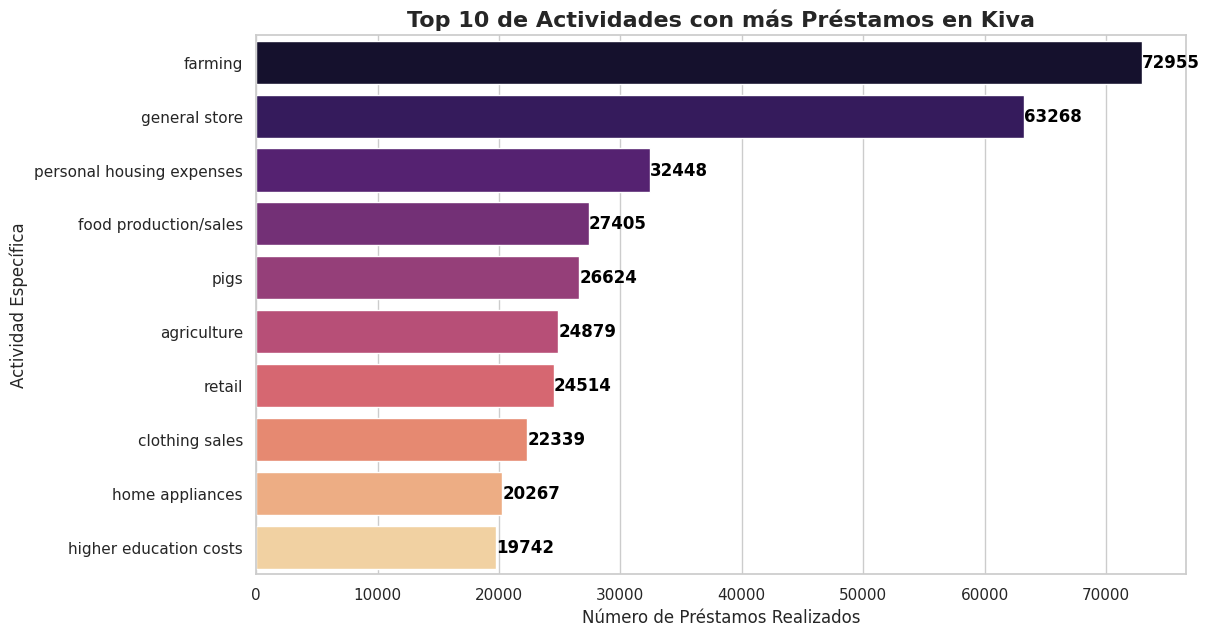

In [19]:
# 1. Calculamos el Top 10 de actividades
top_10_actividades = df['activity'].value_counts().head(10)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_actividades.values,
            y=top_10_actividades.index,
            palette='magma')

# 3. Personalización
plt.title('Top 10 de Actividades con más Préstamos en Kiva', fontsize=16, fontweight='bold')
plt.xlabel('Número de Préstamos Realizados', fontsize=12)
plt.ylabel('Actividad Específica', fontsize=12)

# Añadimos los valores exactos al final de cada barra para mayor claridad
for i, v in enumerate(top_10_actividades.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

In [20]:
#Usamos la tecnica de percenciles, especificamente la 99 sobre loan_amount para garantizar que los promedios no se vean distorsionados por casos exepcionales,
#hicimos un proceso de deteccion y limpieza de valores atipicos
#Identificamos el límite del 99% con el cual nos quedaremos
limite_99 = df['loan_amount'].quantile(0.99)

#Creamos el dataset final conservando datos razonables
df_final = df[df['loan_amount'] <= limite_99].copy()

print(f"Límite razonable detectado: {limite_99} USD")
print(f"Registros conservados: {len(df_final)}")
print(f"Registros eliminados (outliers extremos): {len(df) - len(df_final)}")
#nos damos cuenta de que el 99% de los prestamos de kiva son menores o iguales al monto 5300


Límite razonable detectado: 5300.0 USD
Registros conservados: 651127
Registros eliminados (outliers extremos): 6571


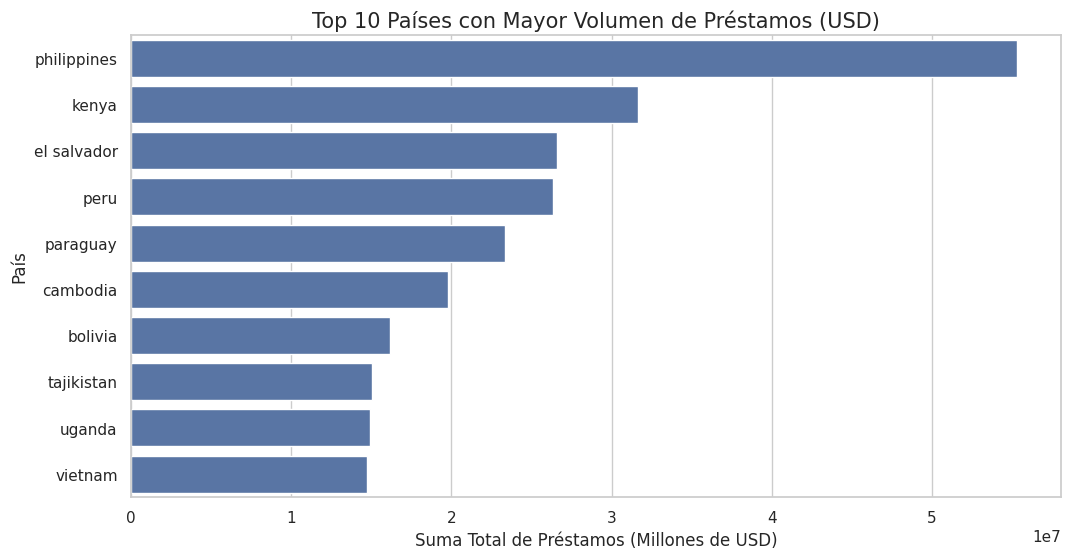

In [21]:
# 1. Agrupamos por país y sumamos el monto de los préstamos
top_paises_monto = df_final.groupby('country')['loan_amount'].sum().sort_values(ascending=False).head(10)

# 2. Creamos el gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=top_paises_monto.values, y=top_paises_monto.index)

# 3. Formateamos para que se vea profesional
plt.title('Top 10 Países con Mayor Volumen de Préstamos (USD)', fontsize=15)
plt.xlabel('Suma Total de Préstamos (Millones de USD)', fontsize=12)
plt.ylabel('País', fontsize=12)

plt.show()

In [22]:
#Categorizamos la columna de género para mejor análisis visual
def categorizar_genero_detallado(genero_str):
    # Si está vacío, marcamos como otro/desconocido
    if pd.isna(genero_str) or genero_str.strip() == "":
        return "Other/Unknown"
    # Convertimos la cadena "female, female, male" en una lista ['female', 'female', 'male']
    lista = [g.strip().lower() for g in str(genero_str).split(',')]
    num_personas = len(lista)
    tiene_female = 'female' in lista
    tiene_male = 'male' in lista
    # --- LÓGICA DE CATEGORÍAS ---
    # 1. Préstamos Individuales (solo una persona)
    if num_personas == 1:
        return "Female" if tiene_female else "Male"
    # 2. Préstamos Grupales (más de una persona)
    else:
        if tiene_female and not tiene_male:
            return "Female Group"
        elif tiene_male and not tiene_female:
            return "Male Group"
        else:
            return "Mixed Group"
# Aplicamos la función
df['gender_category'] = df['borrower_genders'].apply(categorizar_genero_detallado)
# Ver cuántos hay de cada uno para revisar
print(df['gender_category'].value_counts())

gender_category
Female          415841
Male            136085
Female Group     61579
Mixed Group      40380
Male Group        3813
Name: count, dtype: int64


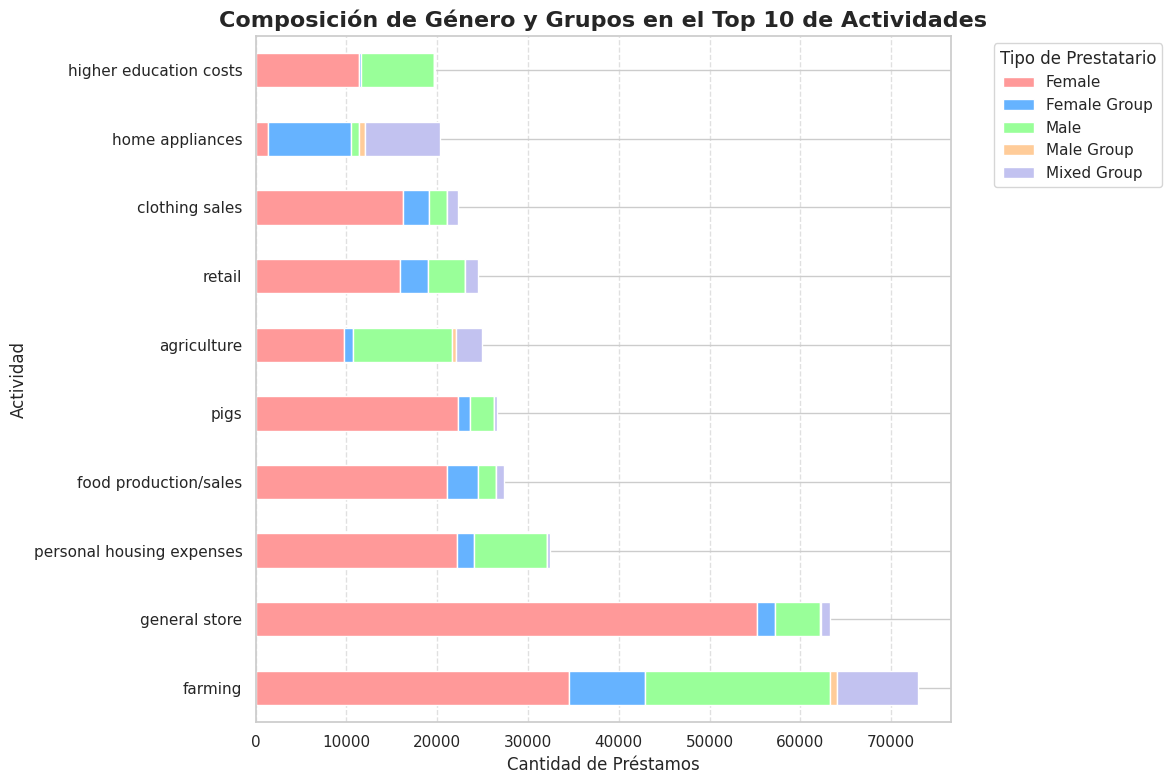

In [23]:
# 1. Definimos las 10 actividades con más préstamos
top_10_actividades = df['activity'].value_counts().head(10).index

# 2. Filtramos el dataframe para quedarnos solo con esas actividades
df_plot = df[df['activity'].isin(top_10_actividades)]

# 3. Creamos una tabla cruzada (Contamos cuántos tipos de género hay por actividad)
# Esto es como hacer una "Tabla Dinámica" en Excel
pivot_df = pd.crosstab(df_plot['activity'], df_plot['gender_category'])

# Reordenamos para que las barras más grandes salgan primero
pivot_df = pivot_df.reindex(top_10_actividades)

# 4. Creamos el gráfico de barras apiladas
pivot_df.plot(kind='barh',
              stacked=True,
              figsize=(12, 8),
              color=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])

# Personalización
plt.title('Composición de Género y Grupos en el Top 10 de Actividades', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Préstamos', fontsize=12)
plt.ylabel('Actividad', fontsize=12)
plt.legend(title='Tipo de Prestatario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
# Definimos las columnas que deberían ser numéricas
columnas_numericas = ['funded_amount', 'loan_amount', 'lender_count', 'term_in_months']

for col in columnas_numericas:
    # Si los datos vienen con comas (ej. "1,200.50"), las quitamos
    # Primero nos aseguramos de que tratamos la columna como texto para poder usar .replace
    df_final[col] = df_final[col].astype(str).str.replace(',', '')

    # Paso 2: Convertimos a número real
    # 'errors=coerce' transformará cualquier texto extraño en NaN (nulo)
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Ajuste fino de tipos
# Ponemos el dinero como decimmal y los meses como enteros
df_final['funded_amount'] = df_final['funded_amount'].astype(float)
df_final['loan_amount'] = df_final['loan_amount'].astype(float)
df_final['lender_count'] = df_final['lender_count'].astype('Int64')
df_final['term_in_months'] = df_final['term_in_months'].astype('Int64')

print("✅ Formatos numéricos corregidos.")
print(df_final[columnas_numericas].dtypes)

✅ Formatos numéricos corregidos.
funded_amount     float64
loan_amount       float64
lender_count        Int64
term_in_months      Int64
dtype: object


In [25]:
# Extraemos el año y el mes de la columna 'date'
df_final['año'] = df_final['date'].dt.year
df_final['mes'] = df_final['date'].dt.month

# Sacamos el nombre del mes para los gráficos
df_final['nombre_mes'] = df_final['date'].dt.month_name()

# Creamos el ratio de fondeo (0 a 1)
df_final['ratio_fondeo'] = df_final['funded_amount'] / df_final['loan_amount']

# Una columna booleana para saber si se fondeó al 100%
df_final['completamente_fondeado'] = df_final['ratio_fondeo'] >= 1.0

# Calculamos los días que tardó en fondearse
# Restamos el momento en que se publicó del momento en que se completó
df_final['dias_fondeo'] = (df_final['funded_time'] - df_final['posted_time']).dt.days

# Si el préstamo no se fondeó, esta columna tendrá nulos, lo cual es correcto.

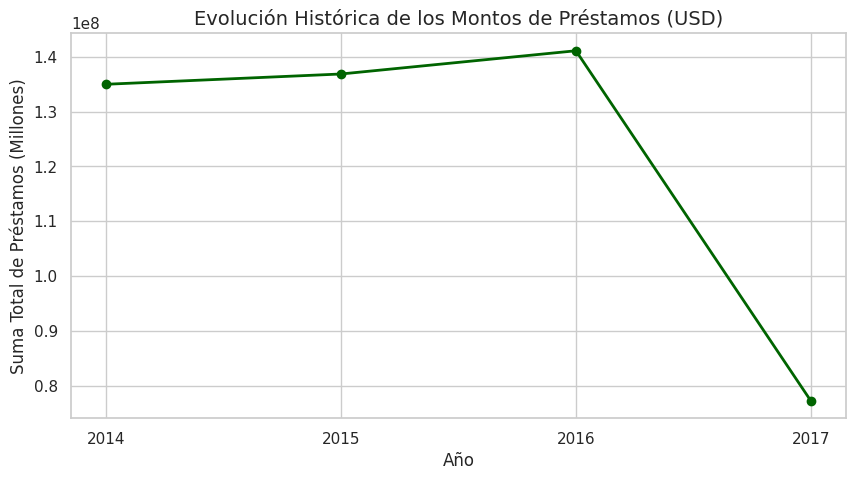

In [26]:
# 1. Agrupamos por año y sumamos el monto de los préstamos
evolucion_anual = df_final.groupby('año')['loan_amount'].sum()

# 2. Creamos el gráfico de líneas
plt.figure(figsize=(10, 5))
plt.plot(evolucion_anual.index, evolucion_anual.values, marker='o', linestyle='-', color='darkgreen', linewidth=2)


# 3. Personalización
plt.title('Evolución Histórica de los Montos de Préstamos (USD)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Suma Total de Préstamos (Millones)', fontsize=12)
plt.xticks(evolucion_anual.index)


plt.show()

In [27]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 651127 entries, 0 to 671204
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   id                      651127 non-null  int64              
 1   funded_amount           651127 non-null  float64            
 2   loan_amount             651127 non-null  float64            
 3   activity                651127 non-null  object             
 4   sector                  651127 non-null  object             
 5   use                     651127 non-null  object             
 6   country_code            651127 non-null  object             
 7   country                 651127 non-null  object             
 8   region                  651127 non-null  object             
 9   currency                651127 non-null  object             
 10  partner_id              651127 non-null  float64            
 11  posted_time             651127 

In [28]:
# Simplificamos la columna de géneros
# Esto evita que se creen cientos de columnas por cada combinación de grupos
df_final['genero_simple'] = df_final['borrower_genders'].apply(
    lambda x: 'female' if x == 'female' else ('male' if x == 'male' else 'group')
)

# 2. Aplicamos One-Hot Encoding a la nueva columna
df_final = pd.get_dummies(df_final, columns=['genero_simple'], prefix='tipo')

# Convertimos los True/False resultantes a 1 y 0
columnas_genero = [col for col in df_final.columns if col.startswith('tipo_')]
df_final[columnas_genero] = df_final[columnas_genero].astype(int)

print("Codificación de género finalizada.")
print(f"Nuevas columnas creadas: {columnas_genero}")
display(df_final[columnas_genero].head())

Codificación de género finalizada.
Nuevas columnas creadas: ['tipo_female', 'tipo_group', 'tipo_male']


,tipo_female,tipo_group,tipo_male
0,1,0,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0


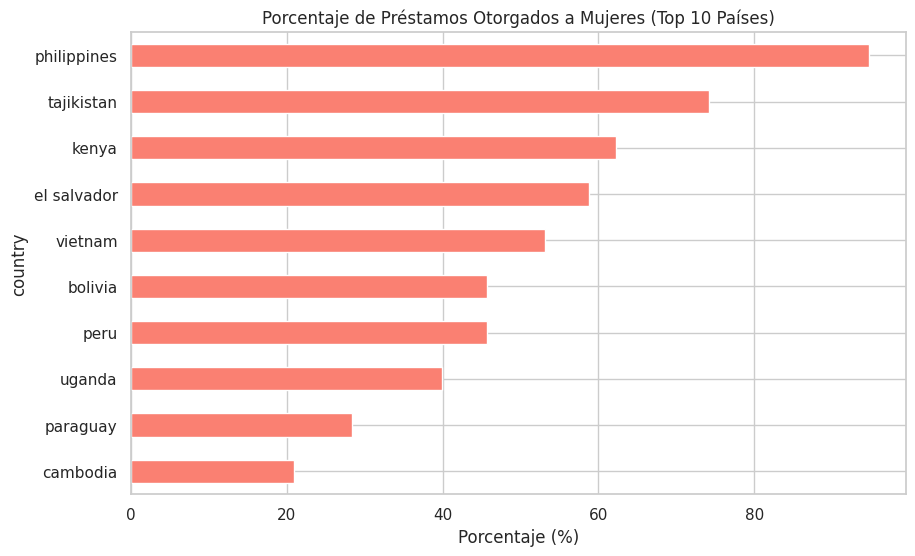

In [29]:
# Guardamos los datos
porcentaje_mujeres = df_final.groupby('country')['tipo_female'].mean().loc[top_paises_monto.index] * 100

# Grafico
plt.figure(figsize=(10,6))
porcentaje_mujeres.sort_values().plot(kind='barh', color='salmon')
plt.title('Porcentaje de Préstamos Otorgados a Mujeres (Top 10 Países)')
plt.xlabel('Porcentaje (%)')
plt.show()

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 657,698
  • Columnas: 20
  • Celdas totales: 13,153,960
  • Datos faltantes: 46,176 (0.35%)
  • Filas duplicadas: 0
  • Uso de memoria: 449.27 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
id,int64,657698,0,0.00%,657698,100.00%,653051
funded_amount,float64,657698,0,0.00%,481,0.07%,300.000000
loan_amount,float64,657698,0,0.00%,479,0.07%,300.000000
activity,object,657698,0,0.00%,163,0.02%,fruits & vegetables
sector,object,657698,0,0.00%,15,0.00%,food
use,object,657698,0,0.00%,400682,60.92%,"to buy seasonal, fresh fruits to sell."
country_code,object,657698,0,0.00%,84,0.01%,pk
country,object,657698,0,0.00%,84,0.01%,pakistan
region,object,657698,0,0.00%,12668,1.93%,lahore
currency,object,657698,0,0.00%,67,0.01%,pkr


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,min,25%,50%,75%,max,std
id,657698.0,990869.766356,653047.0,819681.25,985945.5,1165326.75,1340339.0,197738.226047
funded_amount,657698.0,770.778001,0.0,250.0,450.0,900.0,100000.0,1066.365512
loan_amount,657698.0,816.263163,25.0,275.0,500.0,975.0,100000.0,1110.912347
partner_id,657698.0,178.199616,9.0,126.0,145.0,204.0,536.0,94.247581
term_in_months,657698.0,13.757404,2.0,8.0,13.0,14.0,158.0,8.518592
lender_count,657698.0,20.340442,0.0,7.0,13.0,24.0,2986.0,27.771486
date,657698,2015-11-13 20:28:18.754139136,2014-01-01 00:00:00,2014-12-23 00:00:00,2015-11-26 00:00:00,2016-10-10 00:00:00,2017-07-26 00:00:00,NaN


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


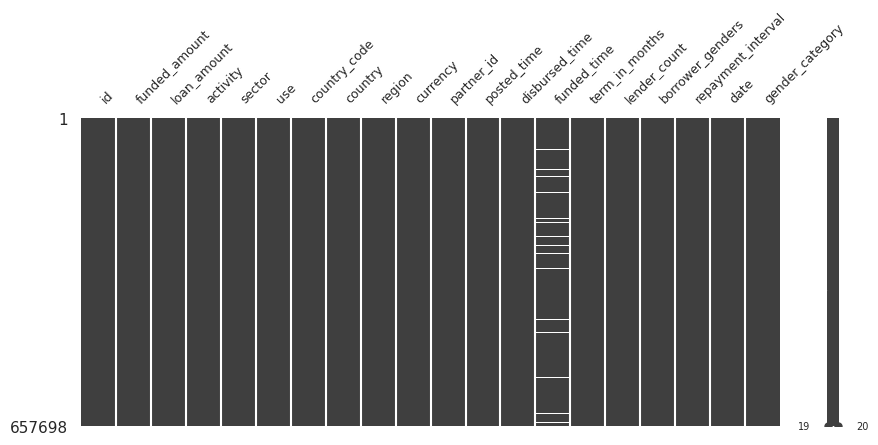

 
------------------------------------------------------------------
¿Hay montos negativos o cero?: False
------------------------------------------------------------------

           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] FORMATO: Convertir a datetime: ['posted_time', 'disbursed_time', 'funded_time', 'date']
------------------------------------------------------------
  TIP: Una vez corregidos estos puntos, vuelve a ejecutar esta celda.


In [30]:
# Volvemos a mostrar los valores de radiografía llamando a las dos funciones
radiografia_tecnica(df)
plan_accion_datos(df)

In [31]:
# Llamamos a la nueva función comparando ambas
comparativo_snapshot(df_original, df)
# Y si quieres el detalle visual del final:
plan_accion_datos(df)

             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"671,205","657,698"
Columnas,20,20
Celdas con Nulos,"300,911","46,176"
% Global de Nulos,2.24%,0.35%
Filas Duplicadas,0,0
Memoria (MB),621.15,449.27



✅ Se han depurado 13,507 filas en total.

           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] FORMATO: Convertir a datetime: ['posted_time', 'disbursed_time', 'funded_time', 'date']
------------------------------------------------------------
  TIP: Una vez corregidos estos puntos, vuelve a ejecutar esta celda.


In [32]:
# correccion de 2 errores de logica
df_final.loc[df_final['funded_amount'] > df_final['loan_amount'], 'funded_amount'] = df_final['loan_amount']

print("✅ Los montos excedentes han sido normalizados.")

✅ Los montos excedentes han sido normalizados.


In [33]:
# --- PRUEBAS DE CALIDAD DE DATOS ---

# Prueba de No-Nulidad en campos clave
campos_criticos = ['loan_amount', 'country', 'sector', 'date']
nulos_criticos = df_final[campos_criticos].isnull().sum().sum()

# Prueba de Unicidad
duplicados_id = df_final['id'].duplicated().sum()

# Prueba de Conteos Esperados
total_filas = len(df_final)
# Verificamos que el monto sea siempre positivo
montos_negativos = (df_final['loan_amount'] <= 0).sum()

print("📊 REPORTE DE CALIDAD FINAL:")
print(f"✅ Nulos en campos críticos (Esperado: 0): {nulos_criticos}")
print(f"✅ Registros duplicados por ID (Esperado: 0): {duplicados_id}")
print(f"✅ Montos menores o iguales a cero (Esperado: 0): {montos_negativos}")
print(f"✅ Total de registros procesados: {total_filas}")

# Una prueba de lógica: ¿funded_amount es siempre <= loan_amount?
logica_monto = (df_final['funded_amount'] > df_final['loan_amount']).sum()
print(f"✅ Errores de lógica en montos (Esperado: 0): {logica_monto}")

📊 REPORTE DE CALIDAD FINAL:
✅ Nulos en campos críticos (Esperado: 0): 0
✅ Registros duplicados por ID (Esperado: 0): 0
✅ Montos menores o iguales a cero (Esperado: 0): 0
✅ Total de registros procesados: 651127
✅ Errores de lógica en montos (Esperado: 0): 0


💡 **Conclusiones**

Empoderamiento Femenino: Existe una predominancia clara de mujeres en la plataforma, especialmente en sectores de comercio minorista y alimentación.
Estructura Grupal: Las mujeres tienden a solicitar créditos en grupos solidarios con más frecuencia que los hombres, lo que sugiere una estructura de apoyo mutuo en microcréditos rurales.
Sectores Específicos: Mientras que el sector agrícola muestra una alta presencia de grupos, las actividades de servicios suelen ser lideradas por individuos.